In [7]:
pip install google-genai


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import io
import sys
import os
import pandas as pd
from google import genai

# Hardcode your Gemini API key here temporarily
os.environ["GEMINI_API_KEY"] = ""YOUR_GEMINI_API_KEY""

# Initialize the official Google GenAI client
# It will automatically pick up the environment variable above
client = genai.Client()

print("✅ Step 1 Complete: Gemini Modules Imported Successfully!")

✅ Step 1 Complete: Gemini Modules Imported Successfully!


# Creating the Code Execution Sandbox

In [4]:
def execute_agent_code(code_string, dataframe):
    """
    Safely executes a string of Python code against a specific DataFrame
    and returns whatever the code prints out using print().
    """
    # Create an isolated local scope containing our dataset and pandas
    local_vars = {"df": dataframe, "pd": pd}
    
    # Intercept and redirect standard output so we can capture print statements
    old_stdout = sys.stdout
    redirected_output = sys.stdout = io.StringIO()
    
    try:
        # Run the code string inside our controlled local scope
        exec(code_string, {}, local_vars)
        sys.stdout = old_stdout
        return redirected_output.getvalue().strip()
    
    except Exception as e:
        # If the AI writes faulty code, capture the exact Python error message
        sys.stdout = old_stdout
        return f"EXECUTION_ERROR: {str(e)}"

print("✅ Step 2 Complete: Code Execution Sandbox Created!")

✅ Step 2 Complete: Code Execution Sandbox Created!


# Building the Autonomous Analyst Agent(The Brain)

In [9]:
class AutonomousAnalyst:
    def __init__(self, model="gemini-2.5-flash"):
        self.model = model

    def analyze(self, df, user_query):
        # 1. Gather structural metadata so Gemini knows what the dataset looks like without downloading all rows
        schema = df.dtypes.to_string()
        sample_rows = df.head(3).to_string()
        
        system_prompt = f"""
        You are a Senior Lead Data Analyst. You have access to a pandas DataFrame called `df`.
        
        DATASET SCHEMA:
        {schema}
        
        SAMPLE ROWS:
        {sample_rows}
        
        YOUR TASK:
        Write Python code to answer the user's request. 
        - Your code must explicitly use `print()` to output the final answer or insights.
        - To generate charts, use `matplotlib` or `seaborn` and save them via `plt.savefig('chart_name.png')`.
        - Return ONLY raw, executable Python code. Do not wrap it in markdown code blocks like ```python. Do not write text explanations outside of your code comments.
        """

        # Setting up conversation turns for memory and potential debugging
        conversation_history = [
            {"role": "user", "parts": [{"text": f"{system_prompt}\n\nInitial Request: {user_query}"}]}
        ]

        # Self-correction loop
        for attempt in range(3):
            print(f"🤖 Agent is thinking... (Attempt {attempt + 1}/3)")
            
            # Call the Google Gemini API using the new official SDK
            response = client.models.generate_content(
                model=self.model,
                contents=conversation_history,
                config={"temperature": 0.1} # Keeps coding logical and focused
            )
            
            generated_code = response.text.strip()
            print("💻 Generated Code:\n" + "-"*30 + f"\n{generated_code}\n" + "-"*30)
            
            # Run the code string inside our Step 2 sandbox
            execution_result = execute_agent_code(generated_code, df)
            
            if "EXECUTION_ERROR" not in execution_result:
                print("✨ Code Executed Successfully!")
                return execution_result
            
            # If an error happens, append it to history so Gemini can fix it
            print(f"⚠️ Code failed with error. Initiating self-correction...")
            conversation_history.append({"role": "model", "parts": [{"text": generated_code}]})
            conversation_history.append({"role": "user", "parts": [{"text": f"Your previous code resulted in this error: {execution_result}. Please fix it and provide the full corrected script."}]})
            
        return "❌ Agent failed to complete the analysis after 3 attempts."

print("✅ Step 3 Complete: Gemini Autonomous Analyst Agent Class Defined!")

✅ Step 3 Complete: Gemini Autonomous Analyst Agent Class Defined!


# Testing our system with a Simulated Dataset

In [10]:
import numpy as np

# 1. Generate a mock 10,000-row transaction dataset
print("📊 Creating mock 10,000-row dataset...")
np.random.seed(42)
mock_data = {
    "Transaction_ID": range(10000, 20000),
    "Department": np.random.choice(["Electronics", "Clothing", "Home", "Beauty"], 10000),
    "Revenue": np.random.uniform(5.0, 500.0, 10000),
    "Discount_Applied": np.random.choice([True, False], 10000, p=[0.3, 0.7]),
    "Units_Sold": np.random.randint(1, 10, 10000)
}
test_df = pd.DataFrame(mock_data)

# Introduce some artificial missing values to test agent flexibility
test_df.loc[test_df["Transaction_ID"] % 500 == 0, "Revenue"] = np.nan

# 2. Initialize the agent (using the Gemini configuration)
analyst = AutonomousAnalyst()

# 3. Run the Test Request
print("\n--- Running Test Query ---")
query = "Calculate the total revenue lost due to missing values in the Revenue column, assuming the average revenue of that specific department for the missing fields."
result = analyst.analyze(test_df, query)

print(f"\nFinal Agent Response:\n{result}")

📊 Creating mock 10,000-row dataset...

--- Running Test Query ---
🤖 Agent is thinking... (Attempt 1/3)
💻 Generated Code:
------------------------------
import pandas as pd
import numpy as np

# Assuming df is already loaded and available as a pandas DataFrame

# Create a copy to avoid modifying the the original DataFrame if it's used elsewhere
df_copy = df.copy()

# Calculate the average revenue for each department, excluding NaNs
department_avg_revenue = df_copy.groupby('Department')['Revenue'].mean()

# Identify rows where Revenue is missing
missing_revenue_rows = df_copy[df_copy['Revenue'].isna()]

# Initialize a variable to store the total lost revenue
total_lost_revenue = 0.0

# Iterate through the rows with missing revenue
for index, row in missing_revenue_rows.iterrows():
    department = row['Department']
    
    # Get the average revenue for the specific department
    # Use .get() with a default of 0 in case a department with missing revenue has no non-missing revenue entrie

# Testing a Visualization Request


--- Running Visualization Test Query ---
🤖 Agent is thinking... (Attempt 1/3)
💻 Generated Code:
------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded and available as a pandas DataFrame

# Create the boxplot
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability
sns.boxplot(x='Department', y='Revenue', data=df)

# Add title and labels
plt.title('Revenue Distribution by Department', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they overlap

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('dept_outliers.png')

# Optionally, print a confirmation message
print("Boxplot 'dept_outliers.png' has been generated successfully.")

# Display the plot (optional, fo

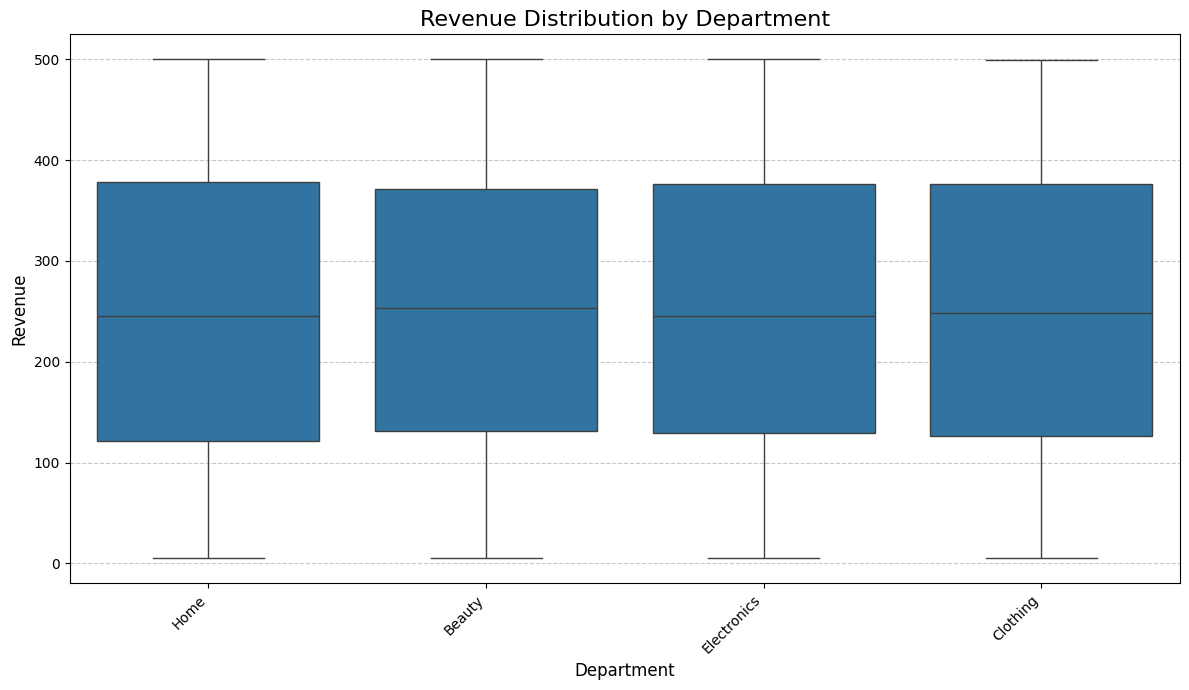

In [11]:
# 5. Run a Visualization Test Request
print("\n--- Running Visualization Test Query ---")
query_2 = "Generate and save a boxplot comparing Revenue distributions across different Departments to help spot luxury pricing outliers. Save it as 'dept_outliers.png'."
result_2 = analyst.analyze(test_df, query_2)

print(f"\nFinal Agent Response:\n{result_2}")

# Setting up the Interactive Dashboard

In [12]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import streamlit as st
import io
import sys
import os
import pandas as pd
from google import genai

# Configure your API key here 
os.environ["GEMINI_API_KEY"] = "your-actual-gemini-key-here"
client = genai.Client()

# --- STEP 2: CODE EXECUTION SANDBOX ---
def execute_agent_code(code_string, dataframe):
    local_vars = {"df": dataframe, "pd": pd}
    old_stdout = sys.stdout
    redirected_output = sys.stdout = io.StringIO()
    try:
        exec(code_string, {}, local_vars)
        sys.stdout = old_stdout
        return redirected_output.getvalue().strip()
    except Exception as e:
        sys.stdout = old_stdout
        return f"EXECUTION_ERROR: {str(e)}"

# --- STEP 3: GEMINI AGENT BRAIN ---
class AutonomousAnalyst:
    def __init__(self, model="gemini-2.5-flash"):
        self.model = model

    def analyze(self, df, user_query):
        schema = df.dtypes.to_string()
        sample_rows = df.head(3).to_string()
        
        system_prompt = f"""
        You are a Senior Lead Data Analyst. You have access to a pandas DataFrame called `df`.
        DATASET SCHEMA:
        {schema}
        SAMPLE ROWS:
        {sample_rows}
        
        YOUR TASK:
        Write Python code to answer the user's request. 
        - Your code must explicitly use `print()` to output the final answer or insights.
        - To generate charts, use `matplotlib` or `seaborn` and save them via `plt.savefig('output_chart.png')`.
        - Return ONLY raw, executable Python code. Do not wrap it in markdown code blocks like ```python. Do not write text explanations outside of your code comments.
        """
        conversation_history = [
            {"role": "user", "parts": [{"text": f"{system_prompt}\n\nInitial Request: {user_query}"}]}
        ]

        for attempt in range(3):
            response = client.models.generate_content(
                model=self.model, contents=conversation_history, config={"temperature": 0.1}
            )
            generated_code = response.text.strip()
            execution_result = execute_agent_code(generated_code, df)
            
            if "EXECUTION_ERROR" not in execution_result:
                return execution_result, generated_code
            
            conversation_history.append({"role": "model", "parts": [{"text": generated_code}]})
            conversation_history.append({"role": "user", "parts": [{"text": f"Your code had this error: {execution_result}. Fix it entirely."}]})
        return "❌ Agent failed to complete the analysis.", None

# --- STREAMLIT UI LAYOUT ---
st.set_page_config(page_title="Autonomous AI Data Analyst", layout="wide")
st.title("🤖 Autonomous AI Data Analyst")
st.subheader("Analyze massive datasets with zero code")

# File uploader sidebar
uploaded_file = st.sidebar.file_uploader("Upload your dataset (CSV or Excel)", type=["csv", "xlsx"])

if uploaded_file is not None:
    # Load dataset into memory
    if uploaded_file.name.endswith('.csv'):
        df = pd.read_csv(uploaded_file)
    else:
        df = pd.read_excel(uploaded_file)
        
    st.write(f"📊 **Loaded dataset:** `{uploaded_file.name}` ({df.shape[0]} rows, {df.shape[1]} columns)")
    st.dataframe(df.head(5), use_container_width=True)
    
    # User query input
    user_query = st.text_input("💬 Ask your dataset a question:", placeholder="e.g., Show me the top departments by revenue or generate a scatter plot.")
    
    if st.button("Run Analysis") and user_query:
        # Delete any old chart artifact to avoid displaying cached images
        if os.path.exists("output_chart.png"):
            os.remove("output_chart.png")
            
        analyst = AutonomousAnalyst()
        
        with st.spinner("🤖 Agent is analyzing columns and executing logic..."):
            result, code = analyst.analyze(df, user_query)
            
        # Display Results split into columns
        col1, col2 = st.columns([1, 1])
        
        with col1:
            st.markdown("### 📊 Agent Insights")
            st.code(result if result else "No text output printed.")
            
            if os.path.exists("output_chart.png"):
                st.markdown("### 📈 Visualizations")
                st.image("output_chart.png", use_container_width=True)
                
        with col2:
            st.markdown("### 💻 Code Executed Behind the Scenes")
            st.code(code, language='python')
else:
    st.info("👈 Please upload a CSV or Excel data file in the sidebar to kick off your analysis.")